<a href="https://colab.research.google.com/github/naominicole27/Analitica-de-Negocios/blob/main/Clustering_K_Means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Caso de Estudio**

En este documento se desarrolla y analiza un modelo Clustering K-Means para la PreAprobación de créditos en una entidad financiera utilizando las variables socioeconómicos de un solicitante de crédito. De acuerdo con lo anterior las variables socioeconómicas son:

Edad: Es la edad que posee el solicitante al momento de solicitar un crédito.

Ingresos: Ingresos recibidos recibidos de una persona como resultado de una actividad comercial.

Egresos: Son los gastos mensuales del solicitante. Gastos de persona a cargo, hijos y servicios públicos.

Monto(EAD): Indica el dinero que una persona solicita a una entidad financiera como crédito.



0. Se procede con la carga de la librería del trabajo

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns        #Herramienta para gráfico

from sklearn.cluster import KMeans   #Herramienta de Clustering

1. Se cargan los datos del trabajo

<Axes: >

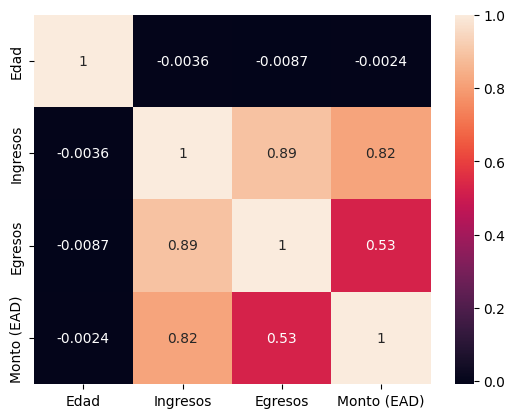

In [ ]:
import pandas as pd
import seaborn as sns # Added this line
nxl='/content/1. Base de Datos - SolicitantesCrédito(USD).xlsx'
XDB=pd.read_excel(nxl,sheet_name=1)    #Base AAA
XD=XDB.iloc [:,[1,10,11,25]]  #Datos de entrada
yd=XDB.iloc[:,32]

#Determinamos la correlación entre las variables
XDB2=XDB.iloc[:,[1,10,11,25]].copy() # Explicitly make a copy to avoid SettingWithCopyWarning
sns.heatmap(XDB2.corr(),annot=True)

2. Se procede con la implementación del modelo K-Means

In [ ]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans # Corrected import statement

NC=5                    #Segmentos o perfiles de clientes
mkm=KMeans(n_clusters=NC,random_state=42)
mkm.fit(XD,yd)          #El modelo busca la mejor relación entre la entrada y la salida

#Obtenemos las características de cada grupo
#Representa los perfiles de las personas mkm.cluster_centers_
Tabla=pd.DataFrame(mkm.cluster_centers_,columns=XD.columns)
display(Tabla)

#Para saber los porcentajes de PreAPR O PreNeg por segmento, sucursal o perfil
ydp=mkm.labels_ #Esto me indica en que cluster queda clasificado cada dato
NDc=np.bincount(ydp)      #Número de datos por segmento
print("El número de datos por cluster es:",NDc)

,Edad,Ingresos,Egresos,Monto (EAD)
0,41.062353,242.798352,213.255141,175.381339
1,40.814394,1943.037897,2034.368232,1151.374380
2,40.842975,1378.277280,825.976626,1500.438821
3,40.995816,1173.957912,1239.367737,656.163350
4,41.129177,711.127537,601.939361,537.170724


El número de datos por cluster es: [2127  264  485  960 2006]


3. Porcentajes de PreAprobación.

In [ ]:
XDB2['Cluster']=mkm.labels_
display(XDB2)

# Add the 'PreApr' column to XDB2
XDB2['PreApr'] = yd

#Determinar el número de PreAprobados y PreNegados por cluster

NApr=XDB2.groupby('Cluster').agg({'PreApr':lambda x: (x==1).sum()})
NPrn=XDB2.groupby('Cluster').agg({'PreApr':lambda x: (x==0).sum()})
#Para que la decisión sea en procentajes
NApr2=NApr/(NApr+NPrn);NPrn2=NPrn/(NApr+NPrn)
df2=pd.DataFrame(np.column_stack((NApr2,NPrn2)),columns=['PreApr','PreNeg'])
display(df2)

,Edad,Ingresos,Egresos,Monto (EAD),Cluster,PreApr
0,38,1356.14400,1685.622667,625.562230,3,1
1,51,286.01600,364.462000,140.031984,0,1
2,37,517.46325,629.208889,284.564492,4,0
3,29,473.27000,551.616889,309.647588,4,1
4,42,750.09175,806.715778,500.663578,4,1
...,...,...,...,...,...,...
5837,48,1207.84800,753.801111,748.041791,3,1
5838,31,1472.77200,953.812889,870.793819,3,1
5839,38,773.01975,672.910667,594.947894,4,1
5840,43,635.50175,780.691556,305.580539,4,1


,PreApr,PreNeg
0,0.137283,0.862717
1,0.962121,0.037879
2,0.973196,0.026804
3,0.772917,0.227083
4,0.559821,0.440179


4.¿Qué pasa si aparece una persona? Edad 30,Ingresos 500, Egresos 200, Monto 150

In [ ]:
import warnings
warnings.filterwarnings('ignore',category=UserWarning)


nueva_persona=np.array([30,500,200,150])
ydp=mkm.predict(nueva_persona.reshape(1,-1))   #reshape: quitarle la estructura
NCl=ydp[0]     #Esto indoca el cluster al que pertenece una persona
print("La persona pertenece al cluster",ydp)
print("El porcentaje de preaprobación para la nueva persona es:",NApr2.iloc[NCl])
print("El porcentaje de prenegación para la nueva persona es:",NPrn2.iloc[NCl])

La persona pertenece al cluster [0]
El porcentaje de preaprobación para la nueva persona es: PreApr    0.137283
Name: 0, dtype: float64
El porcentaje de prenegación para la nueva persona es: PreApr    0.862717
Name: 0, dtype: float64


5. Se procede con la carga de la gráfica de los clusters utilizando las variables ingresos y egresos.

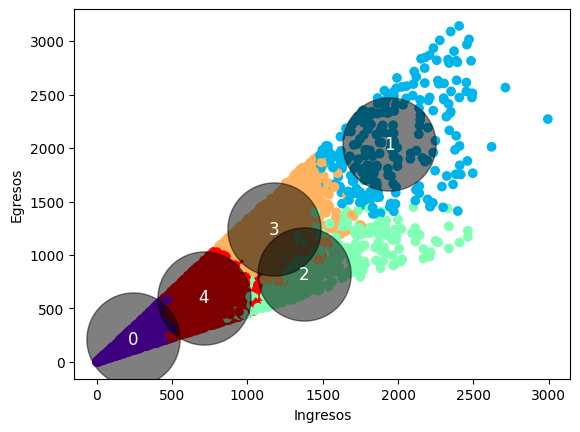

In [ ]:
centers=mkm.cluster_centers_    #Centroides, perfil o segmento
plt.figure()
ing=np.array(XD.iloc[:,1]); egr=np.array(XD.iloc[:,2])

# plt.figure # This line was redundant and didn't create a new figure as intended without ()
plt.scatter(ing,egr,c=mkm.labels_,cmap='rainbow')   #Use mkm.labels_for all data points
plt.scatter(centers[:,1],centers[:,2],c='black',s=4500,alpha=0.5)
plt.xlabel('Ingresos')
plt.ylabel('Egresos')

#Add numbers to the centers
for i, center in enumerate(centers): # Corrected 'enumate' to 'enumerate'
  plt.text(center[1],center[2],str(i),color='white', fontsize=12, ha='center', va='center')

plt.show() # Moved plt.show() to the end to display all elements on one plot

**ANÁLISIS DE RESULTADO**

El el Heatmap se puede observar que las variables que tinen una mayor correlacion entre ellas, son las variables de ingresos y egresos con 89%. Esto indica que si una variable aumenta su valor, la otra tambien se incrementa (si gano mucho, gasto mucho)
Otro correlacion de relevancia es la de la correlacion de ingresos y monto (0.82) personas con altos ingresos piden monton mayores. (bajos ingresos montos menores). Se destaca igualmete que la variable que tiene una mayor correlacion con la variable Preaprobación (Salida) es la variable Ingresos (0.59%).

Deacuerdo con los egmentos o clusters arrojados por el modelo, podemos observar que el cluster 2 son los que poseen los ingresos más altos 1943 t 1378 respectivamente, clusters que igualmente son los que tiene la menor cantidad de solicitantes de crédito 264 y 485. Se destaca el primer cluster, el cual agrupa a las personascon menos ingresos (242), pero es el grupo que posee la mayor cantidad de los solicitantes de crédito (2127)

Se puede observar que el cluster 1 y el cluster 2 agrupan las probailidades mas altas frente a la preaprobación de los créditos con un 96% y 97% de Preaprobación respectivamente. Es importante mencionar que el cluster 0 tuvo los menores porcentajes de Preaprobación, esto promovido por los menores ingresos para las personas que hacen parte de este cluster.